# 01 – Tox21 Exploratory Data Analysis

**Goal.** Establish data quality, endpoint coverage, class balance, missingness, and co-occurrence before modeling.

**Biotech relevance.** The twelve Tox21 endpoints represent pathway-level assay readouts. Understanding imbalance and missing labels is essential because model performance can otherwise be overstated, particularly for rare positives.

**Scientific boundary.** Tox21 is a preclinical screening resource; assay activation is not equivalent to human clinical toxicity.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().resolve().parent
if not (ROOT / "data").exists(): ROOT = Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

from src.preprocessing import load_tox21, endpoint_quality, endpoint_balance, TOX21_ENDPOINTS

path = ROOT / "data/raw/tox21/tox21.csv"
if not path.exists(): path = ROOT / "tox21.csv"
df = load_tox21(path)
print(df.shape)
display(df.head())

(7831, 14)


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


,dtype,missing_n,missing_pct,unique_n
NR-AR,float64,566,7.227685,2
NR-AR-LBD,float64,1073,13.701954,2
NR-AhR,float64,1282,16.370834,2
NR-Aromatase,float64,2010,25.667220,2
NR-ER,float64,1638,20.916869,2
NR-ER-LBD,float64,876,11.186311,2
NR-PPAR-gamma,float64,1381,17.635040,2
SR-ARE,float64,1999,25.526753,2
SR-ATAD5,float64,759,9.692249,2
SR-HSE,float64,1364,17.417954,2


,endpoint,n_valid,positive,negative,positive_pct
0,NR-AR,7265,309,6956,4.253269
1,NR-AR-LBD,6758,237,6521,3.506955
2,NR-AhR,6549,768,5781,11.726981
3,NR-Aromatase,5821,300,5521,5.153754
4,NR-ER,6193,793,5400,12.804780
5,NR-ER-LBD,6955,350,6605,5.032351
6,NR-PPAR-gamma,6450,186,6264,2.883721
7,SR-ARE,5832,942,4890,16.152263
8,SR-ATAD5,7072,264,6808,3.733032
9,SR-HSE,6467,372,6095,5.752281


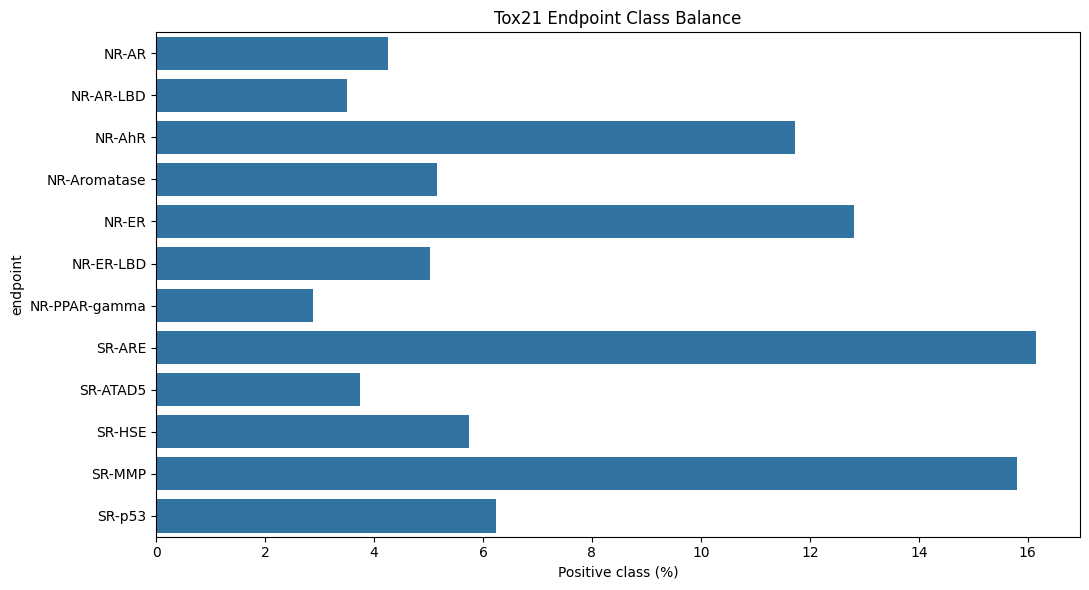

In [2]:
quality = endpoint_quality(df)
balance = endpoint_balance(df)
display(quality)
display(balance)

plt.figure(figsize=(11,6))
sns.barplot(data=balance, x="positive_pct", y="endpoint")
plt.xlabel("Positive class (%)")
plt.title("Tox21 Endpoint Class Balance")
plt.tight_layout()
plt.savefig(ROOT/"reports/figures/tox21_class_balance.png", dpi=200)
plt.show()

## Missingness and endpoint co-occurrence

Missing endpoint labels should be treated as unknown rather than automatically as negative. Co-occurrence can reveal biological relationships and potential assay redundancy.

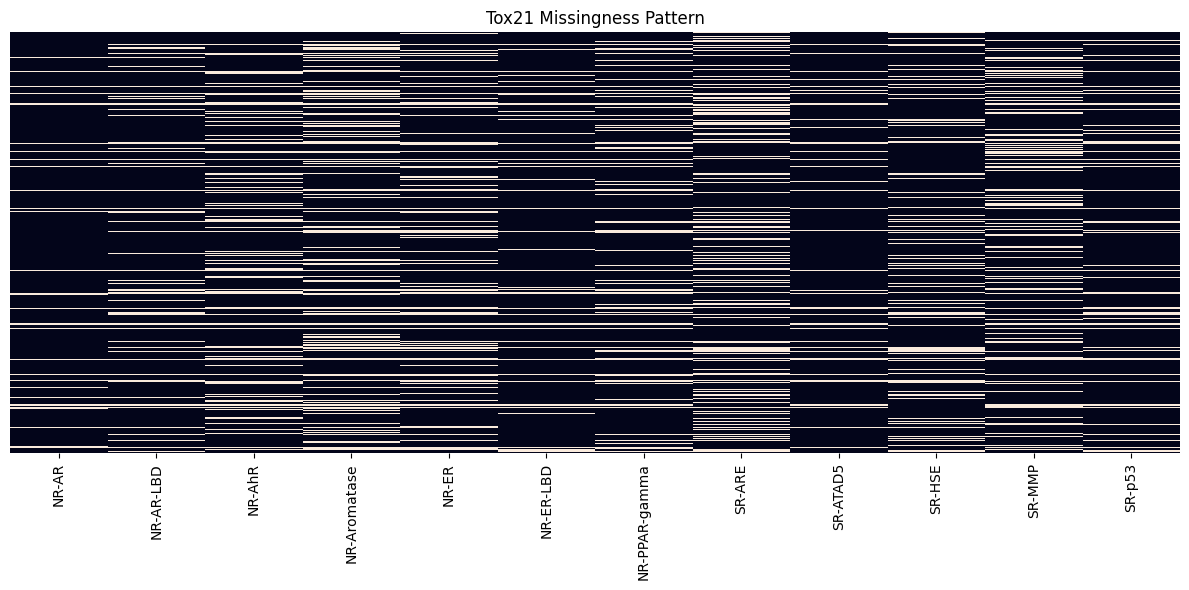

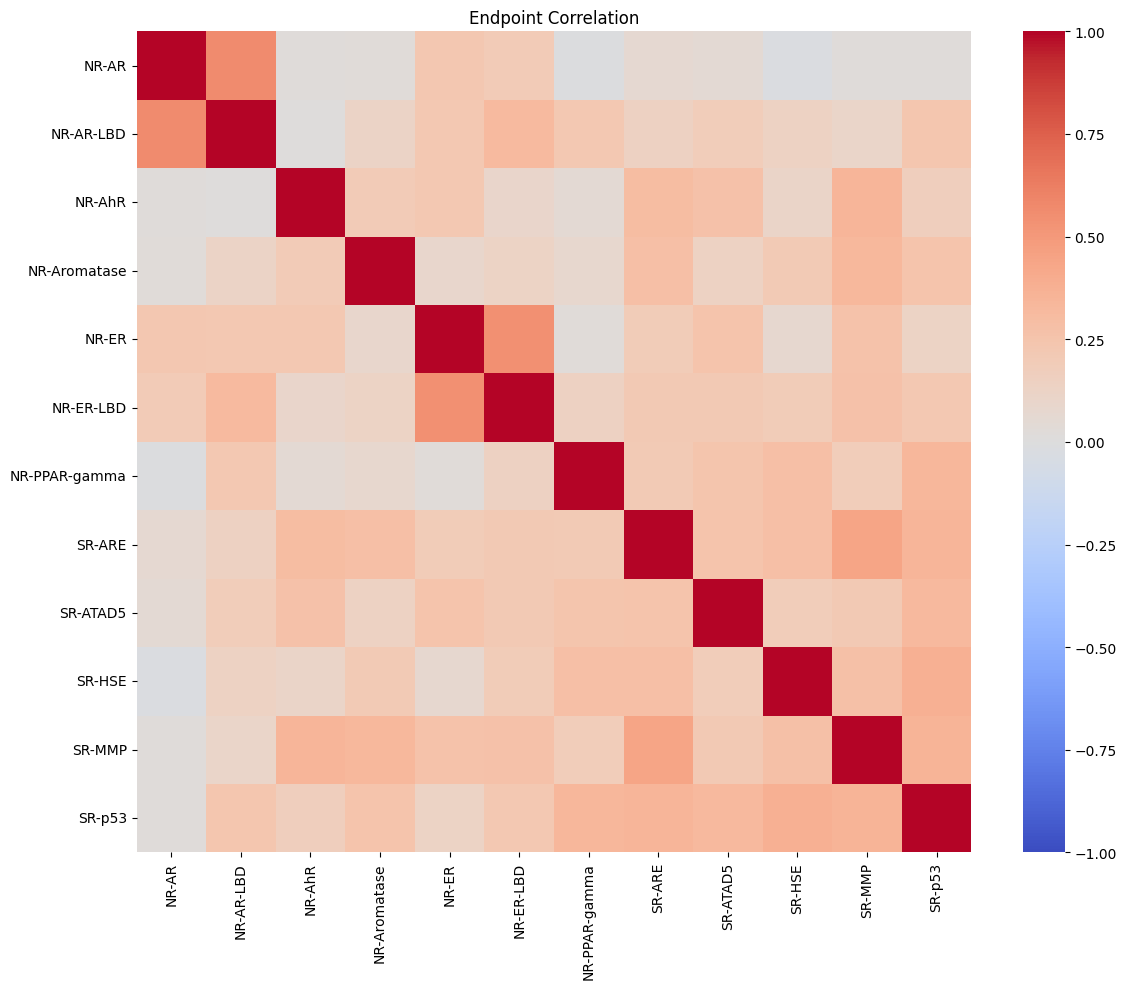

In [3]:
plt.figure(figsize=(12,6))
sns.heatmap(df[TOX21_ENDPOINTS].isna(), cbar=False, yticklabels=False)
plt.title("Tox21 Missingness Pattern")
plt.tight_layout()
plt.savefig(ROOT/"reports/figures/tox21_missingness.png", dpi=200)
plt.show()

corr = df[TOX21_ENDPOINTS].apply(pd.to_numeric, errors="coerce").corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Endpoint Correlation")
plt.tight_layout()
plt.savefig(ROOT/"reports/figures/tox21_endpoint_correlation.png", dpi=200)
plt.show()

In [4]:
OUT = ROOT/"data/processed/tox21"
OUT.mkdir(parents=True, exist_ok=True)
quality.to_csv(OUT/"tox21_quality.csv")
balance.to_csv(OUT/"tox21_balance.csv", index=False)
print("EDA artifacts saved.")

EDA artifacts saved.


### Biotech takeaway

The output of this notebook defines the data-quality constraints for modeling. In production, confirm assay provenance, replicate handling, chemical standardization, and endpoint semantics with the assay owner.